In [9]:
from pathlib import Path

import pandas as pd
from matplotlib.patches import Patch
from pycirclize import Circos
from pycirclize.utils import ColorCycler

TREE_PATH = Path("../data/processed/raxml/Final_tree_18S.raxml.bestTree")
TRAIT_PATH = Path("../data/processed/Trait_data.csv")

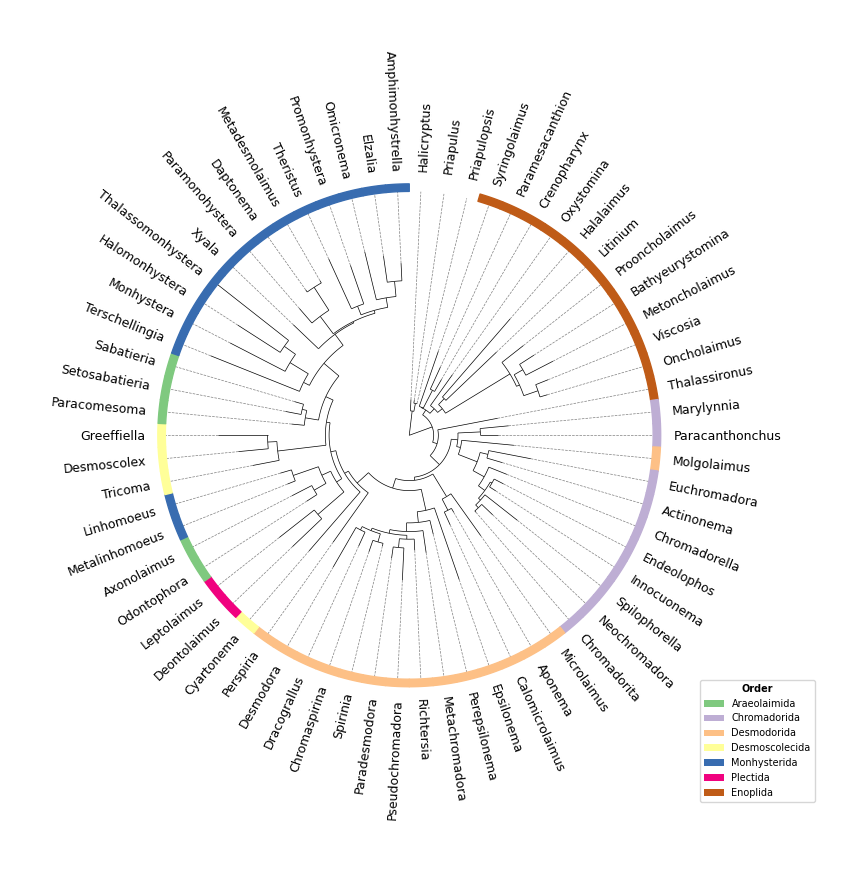

In [12]:
circos, tv = Circos.initialize_from_tree(
    TREE_PATH,
    leaf_label_size=9,
    r_lim=(0,97),
    ladderize=True,
    leaf_label_rmargin=8
)

df = pd.read_csv(TRAIT_PATH, index_col="worms_genus")

sector = tv.track.parent_sector
track = sector.add_track((97,100))
ColorCycler.set_cmap("Accent")
group_color = {order: ColorCycler() for order in df.worms_order.unique()}
for i, label in enumerate(tv.leaf_labels):
    if label not in df.index:
        continue

    track.rect(
        start=i, 
        end=i+1,
        color=group_color[df.loc[label].worms_order],
        lw=1
    )
    

fig = circos.plotfig()

_ = fig.legend(
    handles=[Patch(label=order, fc=color) for order, color in group_color.items()],
    loc="upper left",
    fontsize=7,
    bbox_to_anchor=(0.85,0.2),
    title="Order",
    title_fontproperties={'weight':'bold', "size": 7}
)